In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Starting Test

A Test to see how a model behaves that has a theoretical full connection over the whole network.
Good to see how the information propagate through the system.

In [2]:
xs = np.array([0, 1])
print("Input state:", xs)

w = np.array(
    [
        # x1, x2, h1, h2, o1
        [1, 1, 0, 0, 0], # h1
        [1, 1, 0, 0, 0], # h2
        [0, 0, 1, -2, 0] # o1
    ]
)

b = np.array(
    # h1, h2, o1
    [-0.5, -1.5, -0.5]
)
print("Weights:\n", w)
print("Biases:\n", b)

state = np.array([ 0, 0, 0])
print("Initial state:", state)

def activation(x):
    return (x > 0).astype(float)

Input state: [0 1]
Weights:
 [[ 1  1  0  0  0]
 [ 1  1  0  0  0]
 [ 0  0  1 -2  0]]
Biases:
 [-0.5 -1.5 -0.5]
Initial state: [0 0 0]


## Simple one by one
First look to see how the information transfers in detail.

In [3]:
print("Initial state:", state)
state = np.concatenate((xs, state))
print("State after adding input:", state)

state = w @ state + b
print("State after weight multiplication and bias addition:", state)
state = activation(state)
print("State after ReLU activation:", state)

output = state[-1]
print("Output:", output)


Initial state: [0 0 0]
State after adding input: [0 1 0 0 0]
State after weight multiplication and bias addition: [ 0.5 -0.5 -0.5]
State after ReLU activation: [1. 0. 0.]
Output: 0.0


In [4]:
print("Initial state:", state)
state = np.concatenate((xs, state))
print("State after adding input:", state)

state = w @ state + b
print("State after weight multiplication and bias addition:", state)
state = activation(state)
print("State after ReLU activation:", state)

output = state[-1]
print("Output:", output)

Initial state: [1. 0. 0.]
State after adding input: [0. 1. 1. 0. 0.]
State after weight multiplication and bias addition: [ 0.5 -0.5  0.5]
State after ReLU activation: [1. 0. 1.]
Output: 1.0


## Compressed
Test iterations without looking at the imidiate steps

In [5]:
def iterate(state, x_state, w, b):
    state = np.concatenate((x_state, state))
    state = w @ state + b
    state = activation(state)
    output = state[-1]
    return state, output

In [6]:
# reset state
state = np.array([ 0, 0, 0])
for i in range(5):
    state, output = iterate(state, xs, w, b)
    print(f"Iteration {i+1}: state={state}, output={output}")

Iteration 1: state=[1. 0. 0.], output=0.0
Iteration 2: state=[1. 0. 1.], output=1.0
Iteration 3: state=[1. 0. 1.], output=1.0
Iteration 4: state=[1. 0. 1.], output=1.0
Iteration 5: state=[1. 0. 1.], output=1.0


## Findings
the information travels iteration by iteration through the system.
it means that the output shows the correct output after $N_h-1$ iterations 

# Noisy Version
because the network has a step activation function it is incompatible with normal backpropagation.
but the principal of stochastic input into a step function, mimics a ReLU it may be possible. 
this test is to see how the output behaves if the input is stochastic instead of constant.

In [7]:
state = np.array([ 0, 0, 0])
print("Initial state:", state)
xs = np.array([0, 0.8])
print("Input state:", xs)

x = (np.random.rand(len(xs)) < xs).astype(float)
print("Random triggers:", x)

state = np.concatenate((x, state))
print("State after adding random triggers:", state)
state = w @ state + b
state = activation(state)
print("end state:", state)
output = state[-1]
print("Output:", output)

Initial state: [0 0 0]
Input state: [0.  0.8]
Random triggers: [0. 0.]
State after adding random triggers: [0. 0. 0. 0. 0.]
end state: [0. 0. 0.]
Output: 0.0


In [8]:
x = (np.random.rand(len(xs)) < xs).astype(float)
print("Random triggers:", x)

state = np.concatenate((x, state))
print("State after adding random triggers:", state)
state = w @ state + b
state = activation(state)
print("end state:", state)
output = state[-1]
print("Output:", output)

Random triggers: [0. 1.]
State after adding random triggers: [0. 1. 0. 0. 0.]
end state: [1. 0. 0.]
Output: 0.0


In [9]:
x = (np.random.rand(len(xs)) < xs).astype(float)
print("Random triggers:", x)

state = np.concatenate((x, state))
print("State after adding random triggers:", state)
state = w @ state + b
state = activation(state)
print("end state:", state)
output = state[-1]
print("Output:", output)

Random triggers: [0. 1.]
State after adding random triggers: [0. 1. 1. 0. 0.]
end state: [1. 0. 1.]
Output: 1.0


## Iterate without details

In [10]:
def noisy_iterate(state, x_state, w, b):
    x = (np.random.rand(len(x_state)) < x_state).astype(float)
    state = np.concatenate((x, state))
    state = w @ state + b
    state = activation(state)
    output = state[-1]
    return state, output

In [11]:
state = np.array([ 0, 0, 0])
for i in range(5):
    state, output = noisy_iterate(state, xs, w, b)
    print(f"Iteration {i+1}: state={state}, output={output}")

Iteration 1: state=[1. 0. 0.], output=0.0
Iteration 2: state=[1. 0. 1.], output=1.0
Iteration 3: state=[1. 0. 1.], output=1.0
Iteration 4: state=[1. 0. 1.], output=1.0
Iteration 5: state=[1. 0. 1.], output=1.0


## output averaging
because the output is noisy it has to be averaged to resemble a ReLU

In [12]:
state = np.array([ 0, 0, 0])
outputs = []
states = []
for i in range(5):
    state, output = noisy_iterate(state, xs, w, b)
    outputs.append(output)
    states.append(state)
    print(f"Iteration {i+1}: state={state}, output={output}")

print("average states:", np.mean(states, axis=0))
print("average outputs:", np.mean(outputs, axis=0))

Iteration 1: state=[1. 0. 0.], output=0.0
Iteration 2: state=[0. 0. 1.], output=1.0
Iteration 3: state=[1. 0. 0.], output=0.0
Iteration 4: state=[1. 0. 1.], output=1.0
Iteration 5: state=[1. 0. 1.], output=1.0
average states: [0.8 0.  0.6]
average outputs: 0.6


## Silent iterations
just focusing of that values in the model that emerge and how the output evolves

In [13]:
state = np.array([ 0, 0, 0])
outputs = []
states = []
for i in range(5000):
    state, output = noisy_iterate(state, xs, w, b)
    outputs.append(output)
    states.append(state)

print("average states:", np.mean(states, axis=0))
print("average outputs:", np.mean(outputs, axis=0))

average states: [0.798  0.     0.7978]
average outputs: 0.7978


## Findings
as it is easy to see, the output nodes converge to the correct value.
but it seems that the input probability of x detemins the max average output of the output neuron.
some test by just making the x values random and see how the output behaves

In [14]:
INPUT_TEST = 1000
ITERATIONS = 1000

random_x_states = np.zeros((INPUT_TEST, xs.shape[0]))
average_outputs = np.zeros((INPUT_TEST, 1))
average_states = np.zeros((INPUT_TEST, state.shape[0]))
for i in range(INPUT_TEST):    
    xs = np.random.rand(2)
    random_x_states[i] = xs
    state = np.array([ 0, 0, 0])
    outputs = np.zeros((ITERATIONS, 1))
    states = np.zeros((ITERATIONS, state.shape[0]))
    for j in range(ITERATIONS):
        state, output = noisy_iterate(state, xs, w, b)
        outputs[j] = output
        states[j] = state
    states = np.mean(states, axis=0)
    outputs = np.mean(outputs, axis=0)

    average_states[i] = states
    average_outputs[i] = outputs

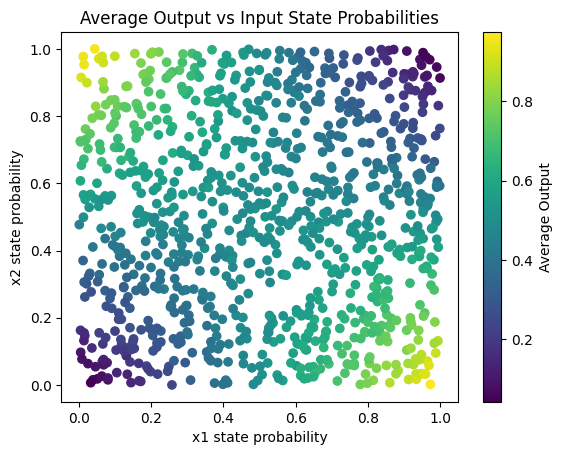

In [15]:
# plot in a 2D plot the x1 and x2 value with a color representing the average output
plt.scatter(random_x_states[:, 0], random_x_states[:, 1], c=average_outputs, cmap='viridis')
plt.colorbar(label='Average Output')
plt.xlabel('x1 state probability')
plt.ylabel('x2 state probability')
plt.title('Average Output vs Input State Probabilities')
plt.show()


## Findings
as it is visible the network completes it's function as XOR but the output doesn't show clear edges where it switches from on to, but it show a gradient and it seems that the input variablility dictates what the maximum output value is.

# Training
is such a network trainable when assuming an activation function of ReLU during backpropagation

In [16]:
LR = 0.1  # learning rate

xs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]) * 0.8  # XOR inputs

ys = np.array([0, 1, 1, 0]) * 0.8  # XOR outputs

print("X:", xs)
print("Y:", ys)

adj = np.array(
    [
        # x1, x2, h1, h2, o1
        [1, 1, 0, 0, 0], # h1
        [1, 1, 0, 0, 0], # h2
        [0, 0, 1, 1, 0] # o1
    ]
)

w = np.array([
    [0.25914638, 0.77686861, 0.         , 0.         , 0.        ],
    [0.5485403 , 0.94806484, 0.         , 0.         , 0.        ],
    [0.         , 0.         , 0.27204435, 0.10031312, 0.        ]
])#np.random.rand(3, 5)  # weights between -1 and 1
w = w * adj  # apply adjacency mask

b = np.array([0.26781006, 0.94080729, 0.56385632])#np.random.rand(3)  # biases between -1 and 1

print("Weights:\n", w)
print("Biases:\n", b)

state = np.repeat([ 0, 0, 0], len(xs)).reshape(len(xs), -1)
print("Initial state:", state)

def activation(x):
    return (x > 0).astype(float)

def activation_prime(x):
    return np.where(x > 0, 1, 0)

def noisy_iterate(state, xs, w, b):
    noise = np.random.rand(*xs.shape)
    x = (noise < xs).astype(float)
    state = np.concatenate((x, state), axis=1)
    a = state @ w.T + b
    state = activation(a)
    output = state[:, -1]
    return a, state, output


X: [[0.  0. ]
 [0.  0.8]
 [0.8 0. ]
 [0.8 0.8]]
Y: [0.  0.8 0.8 0. ]
Weights:
 [[0.25914638 0.77686861 0.         0.         0.        ]
 [0.5485403  0.94806484 0.         0.         0.        ]
 [0.         0.         0.27204435 0.10031312 0.        ]]
Biases:
 [0.26781006 0.94080729 0.56385632]
Initial state: [[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]


In [17]:
yHats = []
states = []
aes = []
for i in range(500):
    a, state, yHat = noisy_iterate(state, xs, w, b)
    states.append(state)
    yHats.append(yHat)
    aes.append(a)


yHat = np.mean(yHats, axis=0)
avg_state = np.mean(states, axis=0)
avg_a = np.mean(aes, axis=0)
print("Average state:", avg_state)
print("yHat:", yHat)
print("ys:", ys)


Average state: [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
yHat: [1. 1. 1. 1.]
ys: [0.  0.8 0.8 0. ]


## Interim Information
to go from the matrix that tells wich node is connected to wich other, the adj matrix can be transposed.
```python
adj = np.array(
    [
        # x1, x2, h1, h2, o1
        [1, 1, 0, 0, 0], # h1 connected to x1 and x2
        [1, 1, 0, 0, 0], # h2 connected to x1 and x2
        [0, 0, 1, 1, 0] # o1 connected to h1 and h2
    ]
)

adj.T = np.array(
    # h1 h2 o1
    [1, 1, 0], # x1 outputs to h1 and h2
    [1, 1, 0], # x2 outputs to h1 and h2
    [0, 0, 1], # h1 outputs to o1
    [0, 0, 1], # h2 outputs to o1
    [0, 0, 0], # o1 has no outputs
)
```

the backpropagation has the same principal as the forward propagation, but the connections are inverted.
the error propagates in the inverse direction through the network over multiple iterations.
it just has an additional step where it updates the weights, wich is not present in the forward propagation.

for the backpropagation the average states of the neurons is used.

In [18]:
error = np.mean((yHat - ys) ** 2)
print("Mean Squared Error:", error)

Mean Squared Error: 0.52


In [ ]:
dJ = yHat - ys
print("dJ:", dJ)
delta = dJ @ activation_prime(avg_a) # error per node
print("Delta:", delta)
delta_state = np.zeros(avg_state.T.shape) # declares the inital state for the delta propagation NxT where N is number of nodes and T is number of time steps
delta_state[-1] = delta
print("Initial delta_state1:\n", delta_state, delta_state.shape)
avg_state = np.concatenate((xs, avg_state), axis=1)
print("Avg state with inputs:", avg_state, avg_state.shape)

dJ: [1.  0.2 0.2 1. ]
Delta: [2.4 2.4 2.4]


ValueError: could not broadcast input array from shape (3,) into shape (4,)

## Weight update of Output layer

In [ ]:
# propagate apply dw to weight from output
dw_o1_full = delta_state @ avg_state
print("dw_o1_full = avg_state @ delta_state1:\n", dw_o1_full, dw_o1_full.shape)
print("adj:\n", adj, adj.shape)
dw =  dw_o1_full.T * adj.T # apply adjacency mask 5x3 * 5x3 = 5x3
print("dw_o1 = adj.T * dw_o1_full:\n", dw, dw.shape)
print("w before update:\n", w, w.shape)
w -= dw.T * LR  # learning rate
print("w after update:\n", w, w.shape)

print("b before update:\n", b, b.shape)
b -= np.mean(delta_state, axis=1) * LR  # learning rate
print("b after update:\n", b, b.shape)

# progagated delta
# expected result is a vector with the delta in it for h1 and h2 (new delta_state)
p_delta = (w.T @ delta_state)
print("propagation_delta = w.T * delta_state1:\n", p_delta)

## Weight update of hidden layer

In [ ]:
delta_state = p_delta * activation_prime(avg_state.T)
delta_state = delta_state[xs.shape[1]:]
print("new delta_state2 = propagation_delta * activation_prime(avg_state.T):\n", delta_state, delta_state.shape, "error of h1 and h2 in all the timesteps")
print("avg_state:\n", avg_state, avg_state.shape)
# propagate apply dw to weight from output
dw_h_full = delta_state @ avg_state
print("dw_h_full = avg_state @ delta_state2:\n", dw_h_full, dw_h_full.shape)
print("adj:\n", adj, adj.shape)
# remove the x inputs from dw_h_full
dw_h =  dw_h_full.T * adj.T # apply adjacency mask 5x3 * 5x3 = 5x3
print("dw_h = adj.T * dw_h_full:\n", dw_h, dw_h.shape)
w -= dw_h.T * LR  # learning rate
print("w after update:\n", w, w.shape)

print("b before update:\n", b, b.shape)
b -= np.mean(delta_state, axis=1) * LR  # learning rate
print("b after update:\n", b, b.shape)

# theorecal next propagation step
p_delta = (w.T @ delta_state)
print("propagation_delta = w.T * delta_state2:\n", p_delta)


## Test of algorythmicality
in theory the update for hidden layer should be applied the same here.
but it is an output layer that cant be updated so a zero matrix is expected at the end

In [ ]:
delta_state3 = p_delta * activation_prime(avg_state.T)
delta_state3 = delta_state3[xs.shape[1]:]
print("new delta_state3 = propagation_delta * activation_prime(avg_state.T):\n", delta_state3, delta_state3.shape, "error of h1 and h2 in all the timesteps")
print("avg_state:\n", avg_state, avg_state.shape)
# propagate apply dw to weight from output
dw_x_full = delta_state3 @ avg_state
print("dw_x_full = avg_state @ delta_state3:\n", dw_x_full, dw_x_full.shape)
print("adj:\n", adj, adj.shape)
# remove the x inputs from dw_x_full
dw_x =  dw_x_full.T * adj.T # apply adjacency mask 5x3 * 5x3 = 5x3
print("dw_x = adj.T * dw_x_full:\n", dw_x, dw_x.shape)
w -= dw_x.T * LR  # learning rate
print("w after update:\n", w, w.shape)

print("b before update:\n", b, b.shape)
b -= np.mean(delta_state3, axis=1) * LR  # learning rate
print("b after update:\n", b, b.shape)

# theorecal next propagation step
p_delta = (w.T @ delta_state3)
print("propagation_delta = w.T * delta_state3:\n", p_delta)

# Generalized Training

## Inizialize

In [ ]:
LR = 0.001  # learning rate

xs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]) * 0.8  # XOR inputs

ys = np.array([0, 1, 1, 0]) * 0.8  # XOR outputs

print("X:", xs)
print("Y:", ys)

adj = np.array(
    [
        # x1, x2, h1, h2, o1
        [1, 1, 0, 0, 0], # h1
        [1, 1, 0, 0, 0], # h2
        [0, 0, 1, 1, 0] # o1
    ]
)

w =  np.random.rand(3, 5)  # weights between -1 and 1
w = w * adj  # apply adjacency mask

b = np.random.rand(3)  # biases between -1 and 1

print("Weights:\n", w)
print("Biases:\n", b)

def activation(x):
    return (x > 0).astype(float)

def activation_prime(x):
    return np.where(x > 0, 1, 0)

def noisy_iterate(state, xs, w, b):
    noise = np.random.rand(*xs.shape)
    x = (noise < xs).astype(float)
    state = np.concatenate((x, state), axis=1)
    a = state @ w.T + b
    state = activation(a)
    output = state[:, -1]
    return a, state, output

## Forward Pass

In [ ]:
def forward(xs, w, b):
    yHats = []
    state = np.repeat([ 0, 0, 0], len(xs)).reshape(len(xs), -1)
    states = []
    inter_states = []
    for i in range(5000):
        a, state, yHat = noisy_iterate(state, xs, w, b)
        states.append(state)
        yHats.append(yHat)
        inter_states.append(a)

    yHat = np.mean(yHats, axis=0)
    avg_state = np.mean(states, axis=0)
    avg_inter_state = np.mean(inter_states, axis=0)

    return yHat, avg_state, avg_inter_state

## Error calculation and preparation

In [ ]:
def init_delta_state(dJ, avg_state, avg_inter_state):
    delta = dJ * activation_prime(avg_inter_state[:, -1])
    delta_state = np.zeros(avg_state.T.shape) # declares the inital state for the delta propagation NxT where N is number of nodes and T is number of time steps
    delta_state[-1] = delta
    return delta_state

def inital_back_iteration(delta_state, w, b, avg_state):
    # propagate apply dw to weight from output
    dw_full = delta_state @ avg_state
    dw =  dw_full.T * adj.T # apply adjacency mask 5x3 * 5x3 = 5x3
    w -= dw.T * LR  # learning rate
    b -= np.mean(delta_state, axis=1) * LR  # learning rate
    p_delta = (w.T @ delta_state)
    return p_delta, w, b

def back_iteration(p_delta, avg_state, avg_inter_state, len_inputs, w, b):
    delta_state = p_delta * activation_prime(avg_inter_state.T)
    delta_state = delta_state[len_inputs:]
    # propagate apply dw to weight from output
    dw_h_full = delta_state @ avg_state
    # remove the x inputs from dw_h_full
    dw_h =  dw_h_full.T * adj.T # apply adjacency mask 5x3 * 5x3 = 5x3
    w -= dw_h.T * LR  # learning rate
    b -= np.mean(delta_state, axis=1) * LR  # learning rate

    # theorecal next propagation step
    p_delta = (w.T @ delta_state)
    return p_delta, w, b

def backpropagation(ys, yHat, avg_state, avg_inter_state, w, b):
    dJ = yHat - ys
    delta_state = init_delta_state(dJ, avg_state, avg_inter_state)
    avg_state = np.concatenate((xs, avg_state), axis=1)
    avg_inter_state = np.concatenate((xs, avg_inter_state), axis=1)
    delta_state, w, b = inital_back_iteration(delta_state, w, b, avg_state) # bakpropagate outputlayer
    delta_state, w, b = back_iteration(delta_state, avg_state, avg_inter_state, xs.shape[1], w, b) # backpropagate hidden layer
    delta_state, w, b = back_iteration(delta_state, avg_state, avg_inter_state, xs.shape[1], w, b) # backpropagate input layer (0 operation)

    return w, b

In [ ]:
start_w = w.copy()
start_b = b.copy()

print("Starting Weights:\n", w)
print("Starting Biases:\n", b)

for epoch in range(10):
    print("#"*100)
    print("Epoch:", epoch)
    yHat, avg_state, avg_inter_state = forward(xs, w, b)
    print("yHat:", yHat)
    print("Mean Squared Error:", np.mean((yHat - ys) ** 2))

    print("Average State:", avg_state, avg_state.shape)
    print("Average Intermediate State:", avg_inter_state, avg_inter_state.shape)

    w_old = w.copy()
    b_old = b.copy()
    w, b = backpropagation(ys, yHat, avg_state, avg_inter_state, w, b)


print("Final Weights:\n", w)
print("Final Biases:\n", b)
print("-"*100)
print("Weight changes:\n", w - start_w)
print("Bias changes:\n", b - start_b)
    